# Imports y carga de datos

In [ ]:
# COMENTADO: bloque de regresión — Ridge, KFold y métricas RMSE/MAE/R² ya no aplican;
# el proyecto cambió a clasificación (LogisticRegression, XGBClassifier, KNN, NN)
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns
# import joblib
# import warnings
# warnings.filterwarnings("ignore") # warnings.filterwarnings("ignore") suprime mensajes de advertencia
#                                   # que no son errores pero llenan el output innecesariamente
#
# from sklearn.linear_model import Ridge # Ridge regresión lineal con regularización
#                                        # es el baseline: el modelo más simple posible
#                                        # regularización significa que penaliza coeficientes muy grandes
#                                        # evita que el modelo se "obsesione" con una sola variable
#
# from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, KFold, cross_val_score 
# # RandomizedSearchCV busca los mejores hiperparámetros probando combinaciones al azar
# # KFold divide los datos en K partes para validación cruzada
# # cross_val_score evalúa el modelo con validación cruzada
#
# from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score)
# # mean_squared_error RMSE: error promedio al cuadrado (penaliza errores grandes)
# # mean_absolute_error MAE: error promedio absoluto (más interpretable)
# # r2_score R²: qué proporción de la variación en puntajes explica el modelo
# # R²=1.0 perfecto, R²=0.0 el modelo no explica nada, R²<0 peor que la media
#
# from xgboost import XGBRegressor
# # XGBRegressor versión de regresión de XGBoost
# # ensamble de árboles de decisión, muy potente para datos tabulares
#
# import tensorflow as tf
# from tensorflow import keras
# from tensorflow.keras import layers
# from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
# # EarlyStopping para el entrenamiento cuando el error deja de mejorar
# # ReduceLROnPlateau reduce la velocidad de aprendizaje cuando se estanca
#
# import os
# os.makedirs("../outputs/figures", exist_ok=True)
# os.makedirs("../outputs/tables", exist_ok=True)
#
# # ── Cargar los dos experimentos ───────────────────────────────────────────────
# experimentos = {}
# # diccionario que va a contener train/test de cada experimento
#
# for exp in ["exp1_se", "exp2_todas"]:
#     experimentos[exp] = {
#         "X_train": pd.read_parquet(f"../data/processed/X_train_{exp}.parquet"),
#         "X_test":  pd.read_parquet(f"../data/processed/X_test_{exp}.parquet"),
#         "y_train": pd.read_parquet(f"../data/processed/y_train_{exp}.parquet").squeeze(),
#         "y_test":  pd.read_parquet(f"../data/processed/y_test_{exp}.parquet").squeeze(),
#         # .squeeze() convierte DataFrame de una columna a Serie
#         # necesario porque lo guardamos con .to_frame() y al cargar vuelve DataFrame
#     }
#     print(f"{exp} train: {experimentos[exp]['X_train'].shape} "
#           f"| test: {experimentos[exp]['X_test'].shape}")
#     print(f"  y_train media: {experimentos[exp]['y_train'].mean():.2f} "
#           f"| y_test media: {experimentos[exp]['y_test'].mean():.2f}")

exp1_se train: (30487, 14) | test: (7622, 14)
  y_train media: 149.60 | y_test media: 149.73
exp2_todas train: (30487, 29) | test: (7622, 29)
  y_train media: 149.60 | y_test media: 149.73


: 

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings("ignore")

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, cross_val_score
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                             classification_report, confusion_matrix, RocCurveDisplay)
from xgboost import XGBClassifier
from tensorflow import keras
from tensorflow.keras import layers
import os

os.makedirs("../outputs/figures", exist_ok=True)
os.makedirs("../outputs/tables", exist_ok=True)

# ── Cargar los dos experimentos ───────────────────────────────────────────────
experimentos = {}
for exp in ["exp1_se", "exp2_todas"]:
    experimentos[exp] = {
        "X_train": pd.read_parquet(f"../data/processed/X_train_{exp}.parquet"),
        "X_test":  pd.read_parquet(f"../data/processed/X_test_{exp}.parquet"),
        "y_train": pd.read_parquet(f"../data/processed/y_train_{exp}.parquet").squeeze(),
        "y_test":  pd.read_parquet(f"../data/processed/y_test_{exp}.parquet").squeeze(),
    }
    print(f"{exp} → train: {experimentos[exp]['X_train'].shape} | test: {experimentos[exp]['X_test'].shape}")

exp1_se → train: (30487, 14) | test: (7622, 14)
exp2_todas → train: (30487, 26) | test: (7622, 26)


# Limpiar NaNs residuales

# Función de evaluación

In [13]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")
# por si quedaron NaNs en exp2_todas (variables con alta cardinalidad)

for exp_name, data in experimentos.items():
    X_train = data["X_train"]
    X_test  = data["X_test"]

    X_train_imp = pd.DataFrame(
        imputer.fit_transform(X_train),
        # fit solo en train aprende la mediana del train
        columns=X_train.columns
    )
    X_test_imp = pd.DataFrame(
        imputer.transform(X_test),
        # transform en test aplica la mediana aprendida del train
        columns=X_test.columns
    )

    experimentos[exp_name]["X_train"] = X_train_imp
    experimentos[exp_name]["X_test"]  = X_test_imp

    nan_train = X_train_imp.isna().sum().sum()
    nan_test  = X_test_imp.isna().sum().sum()
    print(f"{exp_name} → NaNs train: {nan_train} | NaNs test: {nan_test}")
    # ambos deben mostrar 0

exp1_se → NaNs train: 0 | NaNs test: 0
exp2_todas → NaNs train: 0 | NaNs test: 0


Accuracy — proporción de predicciones correctas sobre el total

F1-Score — media armónica de precisión y recall; robusto con clases balanceadas

AUC-ROC — área bajo la curva ROC; mide la capacidad discriminante del modelo (1.0 = perfecto, 0.5 = aleatorio)

# Modelo 1: Regresión Logística (baseline)

In [14]:
resultados = []  # acumula métricas de todos los modelos y experimentos

def evaluar_modelo(nombre, exp_name, modelo, X_test, y_test, y_proba=None):
    if y_proba is not None:
        # caso Red Neuronal: y_proba ya viene calculada, derivamos y_pred del umbral 0.5
        y_pred = (y_proba >= 0.5).astype(int)
    else:
        # caso modelos sklearn: usamos predict y predict_proba del modelo
        y_pred = modelo.predict(X_test)
        y_proba = modelo.predict_proba(X_test)[:, 1]

    acc  = accuracy_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred)
    auc  = roc_auc_score(y_test, y_proba)

    resultados.append({
        "Modelo":      nombre,
        "Experimento": exp_name,
        "Accuracy":    round(acc, 4),
        "F1-Score":    round(f1,  4),
        "AUC-ROC":     round(auc, 4),
    })

    print(f"\n{'─'*50}")
    print(f"{nombre} | {exp_name}")
    print(f"  Accuracy: {acc:.4f}  |  F1: {f1:.4f}  |  AUC-ROC: {auc:.4f}")
    print(classification_report(y_test, y_pred, target_names=["Bajo", "Alto"]))
    return y_pred, y_proba

In [15]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# StratifiedKFold: cada fold conserva la proporción de clases 0/1
# importante en clasificación para que todos los folds sean representativos

param_dist_lr = {
    "C":       [0.001, 0.01, 0.1, 1, 10, 100],
    # C = inverso de la regularización: C pequeño → más regularización
    # regularización penaliza coeficientes grandes para evitar overfitting

    "penalty": ["l1", "l2"],
    # l1 (Lasso): puede llevar coeficientes a 0 → selección implícita de features
    # l2 (Ridge): reduce coeficientes grandes sin anularlos

    "solver":  ["liblinear"],
    # liblinear es compatible con l1 y l2 para datasets medianos
}

preds_lr = {}

for exp_name, data in experimentos.items():
    print(f"\nEntrenando Regresión Logística — {exp_name}...")
    X_train, y_train = data["X_train"], data["y_train"]
    X_test,  y_test  = data["X_test"],  data["y_test"]

    search = RandomizedSearchCV(
        LogisticRegression(max_iter=1000, random_state=42),
        # max_iter=1000 da suficientes iteraciones para converger
        param_distributions=param_dist_lr,
        n_iter=20,
        cv=cv,
        scoring="roc_auc",
        # roc_auc: busca el modelo más discriminante, no solo el más preciso
        random_state=42, n_jobs=-1, verbose=0
    )
    search.fit(X_train, y_train)
    mejor = search.best_estimator_
    print(f"  Mejores params: {search.best_params_}")

    y_pred, y_proba = evaluar_modelo("Reg. Logística", exp_name, mejor, X_test, y_test)
    preds_lr[exp_name] = (y_pred, y_proba)
    joblib.dump(mejor, f"../data/processed/lr_{exp_name}.pkl")


Entrenando Regresión Logística — exp1_se...
  Mejores params: {'solver': 'liblinear', 'penalty': 'l2', 'C': 1}

──────────────────────────────────────────────────
Reg. Logística | exp1_se
  Accuracy: 0.6172  |  F1: 0.6036  |  AUC-ROC: 0.6645
              precision    recall  f1-score   support

        Bajo       0.61      0.65      0.63      3810
        Alto       0.63      0.58      0.60      3812

    accuracy                           0.62      7622
   macro avg       0.62      0.62      0.62      7622
weighted avg       0.62      0.62      0.62      7622


Entrenando Regresión Logística — exp2_todas...
  Mejores params: {'solver': 'liblinear', 'penalty': 'l1', 'C': 10}

──────────────────────────────────────────────────
Reg. Logística | exp2_todas
  Accuracy: 0.6564  |  F1: 0.6580  |  AUC-ROC: 0.7119
              precision    recall  f1-score   support

        Bajo       0.66      0.65      0.65      3810
        Alto       0.66      0.66      0.66      3812

    accuracy    

# Modelo 2: XGBoost

In [16]:
# COMENTADO: XGBRegressor predice valores continuos (regresión);
# se reemplaza por XGBClassifier que predice probabilidades de clase 0/1
# param_dist_xgb = {
#     "n_estimators":     [100, 200, 300, 500],
#     # cuántos árboles construir
#     # más árboles más potente pero más lento
#
#     "max_depth":        [3, 4, 5, 6],
#     # profundidad máxima de cada árbol
#     # profundidad 3 árbol simple, menos riesgo de overfitting
#     # profundidad 6 árbol complejo, más potente pero puede memorizar
#
#     "learning_rate":    [0.01, 0.05, 0.1, 0.2],
#     # qué tan rápido aprende cada árbol nuevo
#     # valor pequeño aprende despacio pero más estable
#
#     "subsample":        [0.6, 0.8, 1.0],
#     # qué fracción de los datos usa para entrenar cada árbol
#     # 0.8 usa el 80% de los datos en cada árbol (añade aleatoriedad útil)
#
#     "colsample_bytree": [0.6, 0.8, 1.0],
#     # qué fracción de las features usa para cada árbol
#     # similar a subsample pero para columnas
#
#     "min_child_weight": [1, 3, 5],
#     # mínimo de muestras en una hoja del árbol
#     # valores grandes árboles más conservadores
#
#     "gamma":            [0, 0.1, 0.3],
#     # pérdida mínima necesaria para hacer una división en el árbol
#     # mayor gamma modelo más conservador
# }
#
# preds_xgb = {}
#
# for exp_name, data in experimentos.items():
#     print(f"\nEntrenando XGBoost — {exp_name}...")
#     X_train, y_train = data["X_train"], data["y_train"]
#     X_test,  y_test  = data["X_test"],  data["y_test"]
#
#     search = RandomizedSearchCV(
#         XGBRegressor(random_state=42, verbosity=0),
#         # verbosity=0 silencia los mensajes internos de XGBoost
#         param_distributions=param_dist_xgb,
#         n_iter=30,
#         # prueba 30 combinaciones aleatorias del espacio de hiperparámetros
#         # balance entre velocidad y calidad de búsqueda
#         cv=cv,
#         scoring="neg_root_mean_squared_error",
#         random_state=42, n_jobs=-1, verbose=0
#     )
#     search.fit(X_train, y_train)
#     mejor = search.best_estimator_
#     print(f"  Mejores params: {search.best_params_}")
#
#     y_pred = mejor.predict(X_test)
#     evaluar_modelo("XGBoost", exp_name, y_test, y_pred)
#     preds_xgb[exp_name] = y_pred
#     joblib.dump(mejor, f"../data/processed/xgb_{exp_name}.pkl")

# PARA CLASIFICACIÓN: XGBClassifier con scoring roc_auc
param_dist_xgb = {
    "n_estimators":     [100, 200, 300, 500],
    # cuántos árboles construir
    "max_depth":        [3, 4, 5, 6],
    # profundidad máxima de cada árbol
    "learning_rate":    [0.01, 0.05, 0.1, 0.2],
    # qué tan rápido aprende cada árbol nuevo
    "subsample":        [0.6, 0.8, 1.0],
    # fracción de datos por árbol (agrega aleatoriedad útil)
    "colsample_bytree": [0.6, 0.8, 1.0],
    # fracción de features por árbol
    "min_child_weight": [1, 3, 5],
    # mínimo de muestras en una hoja
    "gamma":            [0, 0.1, 0.3],
    # pérdida mínima para hacer una división
}

preds_xgb = {}

for exp_name, data in experimentos.items():
    print(f"\nEntrenando XGBoost — {exp_name}...")
    X_train, y_train = data["X_train"], data["y_train"]
    X_test,  y_test  = data["X_test"],  data["y_test"]

    search = RandomizedSearchCV(
        XGBClassifier(random_state=42, verbosity=0, eval_metric="logloss"),
        # eval_metric="logloss" evita el warning interno de XGBoost en clasificación
        param_distributions=param_dist_xgb,
        n_iter=30,
        cv=cv,
        scoring="roc_auc",
        # roc_auc: mide qué tan bien separa el modelo las dos clases
        random_state=42, n_jobs=-1, verbose=0
    )
    search.fit(X_train, y_train)
    mejor = search.best_estimator_
    print(f"  Mejores params: {search.best_params_}")

    y_pred, y_proba = evaluar_modelo("XGBoost", exp_name, mejor, X_test, y_test)
    preds_xgb[exp_name] = (y_pred, y_proba)
    joblib.dump(mejor, f"../data/processed/xgb_{exp_name}.pkl")


Entrenando XGBoost — exp1_se...
  Mejores params: {'subsample': 0.6, 'n_estimators': 500, 'min_child_weight': 3, 'max_depth': 6, 'learning_rate': 0.01, 'gamma': 0.1, 'colsample_bytree': 0.8}

──────────────────────────────────────────────────
XGBoost | exp1_se
  Accuracy: 0.6452  |  F1: 0.6282  |  AUC-ROC: 0.6995
              precision    recall  f1-score   support

        Bajo       0.63      0.69      0.66      3810
        Alto       0.66      0.60      0.63      3812

    accuracy                           0.65      7622
   macro avg       0.65      0.65      0.64      7622
weighted avg       0.65      0.65      0.64      7622


Entrenando XGBoost — exp2_todas...
  Mejores params: {'subsample': 0.8, 'n_estimators': 500, 'min_child_weight': 3, 'max_depth': 6, 'learning_rate': 0.01, 'gamma': 0, 'colsample_bytree': 0.6}

──────────────────────────────────────────────────
XGBoost | exp2_todas
  Accuracy: 0.6719  |  F1: 0.6601  |  AUC-ROC: 0.7314
              precision    recall  f1

# Modelo 3: KNN

In [17]:
from sklearn.neighbors import KNeighborsClassifier

param_dist_knn = {
    "n_neighbors": [3, 5, 7, 11, 15, 21, 31],
    # k pequeño → muy sensible al ruido local (riesgo de overfitting)
    # k grande → decisiones más suaves (riesgo de underfitting)

    "weights": ["uniform", "distance"],
    # uniform → cada vecino vota con el mismo peso
    # distance → vecinos más cercanos pesan más en la decisión

    "metric": ["euclidean", "manhattan"],
    # euclidean → distancia en línea recta entre puntos
    # manhattan → suma de diferencias absolutas, menos sensible a outliers
}

preds_knn = {}

for exp_name, data in experimentos.items():
    print(f"\nEntrenando KNN — {exp_name}...")
    X_train, y_train = data["X_train"], data["y_train"]
    X_test,  y_test  = data["X_test"],  data["y_test"]

    search = RandomizedSearchCV(
        KNeighborsClassifier(),
        param_distributions=param_dist_knn,
        n_iter=20,
        cv=cv,
        scoring="roc_auc",
        random_state=42, n_jobs=-1, verbose=0
    )
    search.fit(X_train, y_train)
    mejor = search.best_estimator_
    print(f"  Mejores params: {search.best_params_}")

    y_pred, y_proba = evaluar_modelo("KNN", exp_name, mejor, X_test, y_test)
    preds_knn[exp_name] = (y_pred, y_proba)
    joblib.dump(mejor, f"../data/processed/knn_{exp_name}.pkl")


Entrenando KNN — exp1_se...
  Mejores params: {'weights': 'uniform', 'n_neighbors': 31, 'metric': 'manhattan'}

──────────────────────────────────────────────────
KNN | exp1_se
  Accuracy: 0.6288  |  F1: 0.6174  |  AUC-ROC: 0.6796
              precision    recall  f1-score   support

        Bajo       0.62      0.66      0.64      3810
        Alto       0.64      0.60      0.62      3812

    accuracy                           0.63      7622
   macro avg       0.63      0.63      0.63      7622
weighted avg       0.63      0.63      0.63      7622


Entrenando KNN — exp2_todas...
  Mejores params: {'weights': 'uniform', 'n_neighbors': 31, 'metric': 'manhattan'}

──────────────────────────────────────────────────
KNN | exp2_todas
  Accuracy: 0.6573  |  F1: 0.6513  |  AUC-ROC: 0.7124
              precision    recall  f1-score   support

        Bajo       0.65      0.67      0.66      3810
        Alto       0.66      0.64      0.65      3812

    accuracy                           

# Modelo 4: Red Neuronal


Entrenando Red Neuronal — exp1_se...
  Entrenado en 41 épocas

──────────────────────────────────────────────────
Red Neuronal | exp1_se
  Accuracy: 0.6438  |  F1: 0.6342  |  AUC-ROC: 0.6966
              precision    recall  f1-score   support

        Bajo       0.64      0.67      0.65      3810
        Alto       0.65      0.62      0.63      3812

    accuracy                           0.64      7622
   macro avg       0.64      0.64      0.64      7622
weighted avg       0.64      0.64      0.64      7622



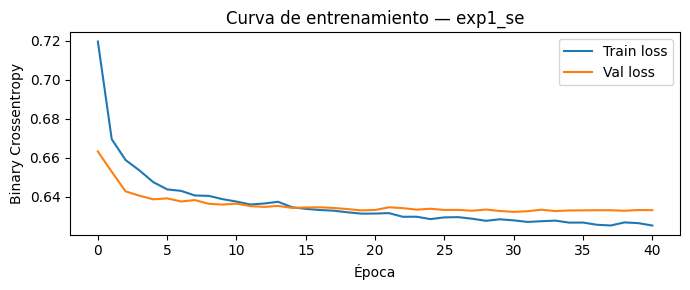


Entrenando Red Neuronal — exp2_todas...
  Entrenado en 43 épocas

──────────────────────────────────────────────────
Red Neuronal | exp2_todas
  Accuracy: 0.6741  |  F1: 0.6641  |  AUC-ROC: 0.7319
              precision    recall  f1-score   support

        Bajo       0.66      0.70      0.68      3810
        Alto       0.69      0.64      0.66      3812

    accuracy                           0.67      7622
   macro avg       0.67      0.67      0.67      7622
weighted avg       0.67      0.67      0.67      7622



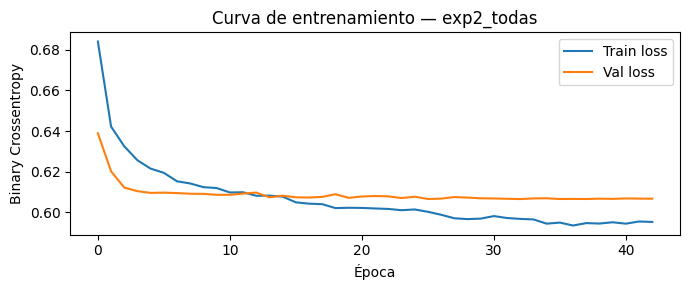

In [18]:
# COMENTADO: red neuronal de regresión — salida lineal y pérdida MSE;
# se reemplaza por una red con salida sigmoid y pérdida binary_crossentropy
# preds_nn = {}
#
# def construir_mlp(input_dim):
#     # input_dim → número de features que entran a la red
#     # cambia entre exp1 (14 features) y exp2 (~34 features)
#
#     model = keras.Sequential([
#         layers.Input(shape=(input_dim,)),
#         # capa de entrada: recibe un vector de input_dim números
#
#         layers.Dense(128, activation="relu"),
#         # capa densa: 128 neuronas, cada una conectada a todas las entradas
#         # relu → función de activación: si el valor es negativo lo hace 0
#         # introduce no-linealidad: permite aprender patrones complejos
#
#         layers.BatchNormalization(),
#         # normaliza las activaciones dentro del batch
#         # estabiliza el entrenamiento y acelera la convergencia
#
#         layers.Dropout(0.3),
#         # apaga aleatoriamente el 30% de las neuronas en cada paso
#         # evita que la red memorice los datos de entrenamiento (overfitting)
#
#         layers.Dense(64, activation="relu"),
#         # segunda capa: 64 neuronas (la red se va haciendo más estrecha)
#
#         layers.BatchNormalization(),
#         layers.Dropout(0.2),
#
#         layers.Dense(32, activation="relu"),
#         # tercera capa: 32 neuronas
#
#         layers.Dropout(0.1),
#
#         layers.Dense(1, activation="linear"),
#         # capa de salida: 1 neurona con activación lineal
#         # linear → no transforma el valor, lo deja como número real
#         # CLAVE para regresión: sin esta activación no puede predecir puntajes continuos
#         # (en clasificación usábamos "sigmoid" que da valores entre 0 y 1)
#     ])
#
#     model.compile(
#         optimizer="adam",
#         # adam → algoritmo de optimización adaptativo, el más usado en redes neuronales
#         loss="mse",
#         # mse = mean squared error → función que la red minimiza durante el entrenamiento
#         metrics=["mae"]
#         # mae se reporta en cada época para monitorear el progreso
#     )
#     return model
#
# callbacks = [
#     EarlyStopping(
#         monitor="val_loss",
#         # monitorea el error en el conjunto de validación
#         patience=10,
#         # si el error no mejora en 10 épocas consecutivas → para el entrenamiento
#         restore_best_weights=True
#         # al parar, restaura los pesos de la época con menor val_loss
#         # evita que el modelo se quede con una versión sobreentrenada
#     ),
#     ReduceLROnPlateau(
#         monitor="val_loss",
#         factor=0.5,
#         # si el error no mejora → multiplica el learning rate por 0.5
#         # ejemplo: lr=0.001 → lr=0.0005
#         patience=5,
#         verbose=0
#     ),
# ]
#
# for exp_name, data in experimentos.items():
#     print(f"\nEntrenando Red Neuronal — {exp_name}...")
#     X_train = data["X_train"].values
#     X_test  = data["X_test"].values
#     y_train = data["y_train"].values
#     y_test  = data["y_test"].values
#     # .values → convierte DataFrame/Serie a array numpy
#     # keras trabaja mejor con arrays numpy que con DataFrames
#
#     model = construir_mlp(input_dim=X_train.shape[1])
#     # X_train.shape[1] → número de columnas = número de features
#
#     history = model.fit(
#         X_train, y_train,
#         validation_split=0.15,
#         # usa el 15% del train como validación interna
#         # el modelo no aprende de este 15%, solo lo usa para monitorear
#         epochs=100,
#         # máximo 100 épocas (EarlyStopping parará antes si no mejora)
#         batch_size=256,
#         # procesa 256 estudiantes a la vez antes de actualizar los pesos
#         # batch más grande → entrenamiento más rápido pero menos preciso
#         callbacks=callbacks,
#         verbose=0
#         # verbose=0 → no imprime el progreso época por época
#     )
#     print(f"  Entrenado en {len(history.history['loss'])} épocas")
#     # cuántas épocas corrió antes de que EarlyStopping parara
#
#     y_pred = model.predict(X_test, verbose=0).flatten()
#     # .flatten() → convierte array de forma (N,1) a (N,) → una dimensión
#     evaluar_modelo("Red Neuronal", exp_name,
#                    data["y_test"].values, y_pred)
#     preds_nn[exp_name] = y_pred
#     model.save(f"../data/processed/nn_{exp_name}.keras")
#
#     # Curva de pérdida por época
#     fig, ax = plt.subplots(figsize=(7, 3))
#     ax.plot(history.history["loss"],     label="Train loss")
#     ax.plot(history.history["val_loss"], label="Val loss")
#     # si val_loss sube mientras train loss baja → overfitting
#     # si ambas bajan juntas → el modelo está aprendiendo bien
#     ax.set_title(f"Curva de entrenamiento — {exp_name}")
#     ax.set_xlabel("Época")
#     ax.set_ylabel("MSE")
#     ax.legend()
#     plt.tight_layout()
#     plt.savefig(f"../outputs/figures/nn_loss_{exp_name}.png", dpi=150)
#     plt.show()

# PARA CLASIFICACIÓN: misma arquitectura, distintas capas de salida y función de pérdida
preds_nn = {}

def construir_mlp_clf(input_dim):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),

        layers.Dense(128, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        layers.Dense(64, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(0.2),

        layers.Dense(32, activation="relu"),
        layers.Dropout(0.1),

        layers.Dense(1, activation="sigmoid"),
        # sigmoid → salida entre 0 y 1, interpretada como P(clase=1)
        # CLAVE para clasificación binaria: reemplaza la salida "linear" de regresión
    ])
    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        # binary_crossentropy mide la diferencia entre P(clase=1) y la etiqueta real
        # es la función de pérdida estándar para clasificación binaria
        metrics=["accuracy"],
    )
    return model

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=10, restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=5, verbose=0
    ),
]

for exp_name, data in experimentos.items():
    print(f"\nEntrenando Red Neuronal — {exp_name}...")
    X_train = data["X_train"].values
    X_test  = data["X_test"].values
    y_train = data["y_train"].values
    y_test  = data["y_test"].values

    model = construir_mlp_clf(input_dim=X_train.shape[1])

    history = model.fit(
        X_train, y_train,
        validation_split=0.15,
        epochs=100,
        batch_size=256,
        callbacks=callbacks,
        verbose=0,
    )
    print(f"  Entrenado en {len(history.history['loss'])} épocas")

    y_proba = model.predict(X_test, verbose=0).flatten()
    # predict devuelve P(clase=1) para cada estudiante
    y_pred  = (y_proba >= 0.5).astype(int)
    # umbral 0.5: si la probabilidad es >= 50% se predice clase 1 (alto)

    evaluar_modelo("Red Neuronal", exp_name,
                   None, X_test, data["y_test"].values,
                   y_proba=y_proba)
    # pasamos None como modelo y y_proba explícito porque Keras no tiene predict_proba
    preds_nn[exp_name] = (y_pred, y_proba)
    model.save(f"../data/processed/nn_{exp_name}.keras")

    fig, ax = plt.subplots(figsize=(7, 3))
    ax.plot(history.history["loss"],     label="Train loss")
    ax.plot(history.history["val_loss"], label="Val loss")
    ax.set_title(f"Curva de entrenamiento — {exp_name}")
    ax.set_xlabel("Época")
    ax.set_ylabel("Binary Crossentropy")
    ax.legend()
    plt.tight_layout()
    plt.savefig(f"../outputs/figures/nn_loss_{exp_name}.png", dpi=150)
    plt.show()

# Tabla comparativa


════════════════════════════════════════════════════════════
TABLA COMPARATIVA DE MODELOS — CLASIFICACIÓN
════════════════════════════════════════════════════════════
        Modelo Experimento  Accuracy  F1-Score  AUC-ROC
       XGBoost     exp1_se    0.6452    0.6282   0.6995
  Red Neuronal     exp1_se    0.6438    0.6342   0.6966
           KNN     exp1_se    0.6288    0.6174   0.6796
Reg. Logística     exp1_se    0.6172    0.6036   0.6645
  Red Neuronal  exp2_todas    0.6741    0.6641   0.7319
       XGBoost  exp2_todas    0.6719    0.6601   0.7314
           KNN  exp2_todas    0.6573    0.6513   0.7124
Reg. Logística  exp2_todas    0.6564    0.6580   0.7119
════════════════════════════════════════════════════════════
Accuracy y F1 entre 0 y 1 | AUC-ROC entre 0.5 (azar) y 1.0 (perfecto)


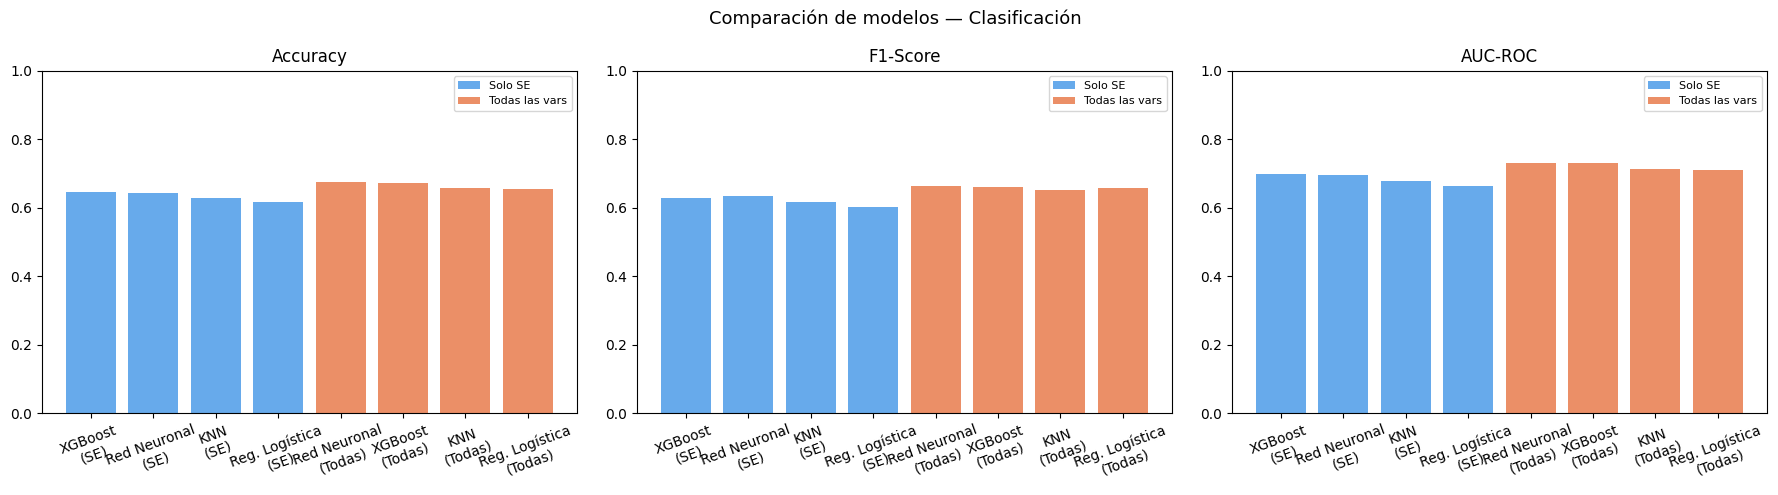

In [19]:
# COMENTADO: tabla de regresión — columnas RMSE/MAE/R² y orden por RMSE;
# se reemplaza por tabla de clasificación con Accuracy/F1/AUC-ROC
# df_resultados = pd.DataFrame(resultados).sort_values(
#     ["Experimento", "RMSE"], ascending=[True, True]
#     # ordena por experimento y dentro de cada uno por RMSE de menor a mayor
#     # el mejor modelo queda arriba
# )
#
# print("\n" + "═"*55)
# print("TABLA COMPARATIVA DE MODELOS")
# print("═"*55)
# print(df_resultados.to_string(index=False))
# print("═"*55)
# print("RMSE y MAE en puntos Saber Pro | R² entre 0 y 1")
#
# df_resultados.to_csv("../outputs/tables/comparacion_modelos.csv", index=False)
#
# # Gráfica de barras para los 3 modelos y 2 experimentos
# fig, axes = plt.subplots(1, 3, figsize=(15, 5))
# metricas = ["RMSE", "MAE", "R²"]
# colores  = {"exp1_se": "#4C9BE8", "exp2_todas": "#E87B4C"}
#
# for ax, metrica in zip(axes, metricas):
#     for exp_name, grupo in df_resultados.groupby("Experimento"):
#         etiquetas = [f"{m}\n({'SE' if exp_name=='exp1_se' else 'Todas'})"
#                      for m in grupo["Modelo"]]
#         ax.bar(etiquetas, grupo[metrica],
#                color=colores[exp_name], alpha=0.85,
#                label="Solo SE" if exp_name == "exp1_se" else "Todas las vars")
#     ax.set_title(metrica)
#     ax.legend(fontsize=8)
#     ax.tick_params(axis="x", rotation=15)
#
# plt.suptitle("Comparación de modelos — Regresión", fontsize=13)
# plt.tight_layout()
# plt.savefig("../outputs/figures/comparacion_modelos.png", dpi=150)
# plt.show()

# PARA CLASIFICACIÓN: tabla con métricas de discriminación
df_resultados = pd.DataFrame(resultados).sort_values(
    ["Experimento", "AUC-ROC"], ascending=[True, False]
    # ordena por experimento y dentro de cada uno por AUC-ROC de mayor a menor
    # el mejor modelo queda arriba
)

print("\n" + "═"*60)
print("TABLA COMPARATIVA DE MODELOS — CLASIFICACIÓN")
print("═"*60)
print(df_resultados.to_string(index=False))
print("═"*60)
print("Accuracy y F1 entre 0 y 1 | AUC-ROC entre 0.5 (azar) y 1.0 (perfecto)")

df_resultados.to_csv("../outputs/tables/comparacion_modelos.csv", index=False)

# Gráfica de barras para los 4 modelos y 2 experimentos
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metricas = ["Accuracy", "F1-Score", "AUC-ROC"]
colores  = {"exp1_se": "#4C9BE8", "exp2_todas": "#E87B4C"}

for ax, metrica in zip(axes, metricas):
    for exp_name, grupo in df_resultados.groupby("Experimento"):
        etiquetas = [f"{m}\n({'SE' if exp_name=='exp1_se' else 'Todas'})"
                     for m in grupo["Modelo"]]
        ax.bar(etiquetas, grupo[metrica],
               color=colores[exp_name], alpha=0.85,
               label="Solo SE" if exp_name == "exp1_se" else "Todas las vars")
    ax.set_ylim(0, 1)
    ax.set_title(metrica)
    ax.legend(fontsize=8)
    ax.tick_params(axis="x", rotation=20)

plt.suptitle("Comparación de modelos — Clasificación", fontsize=13)
plt.tight_layout()
plt.savefig("../outputs/figures/comparacion_modelos.png", dpi=150)
plt.show()

# Visualizaciones de clasificación

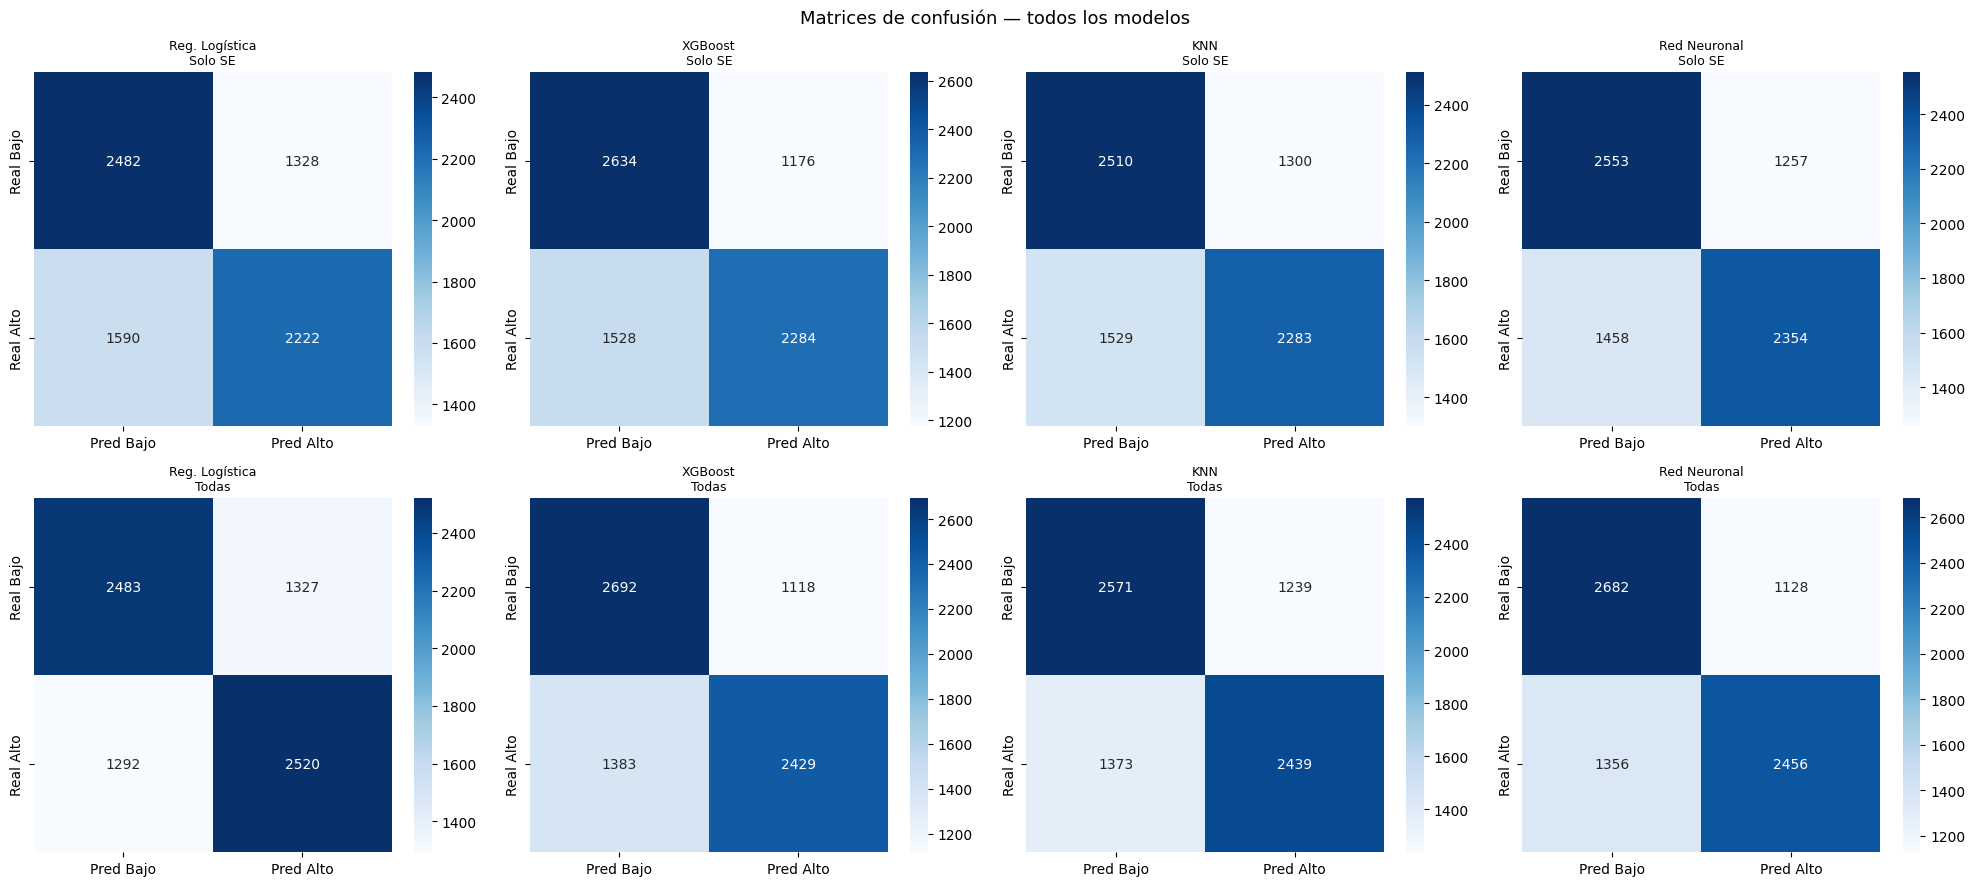

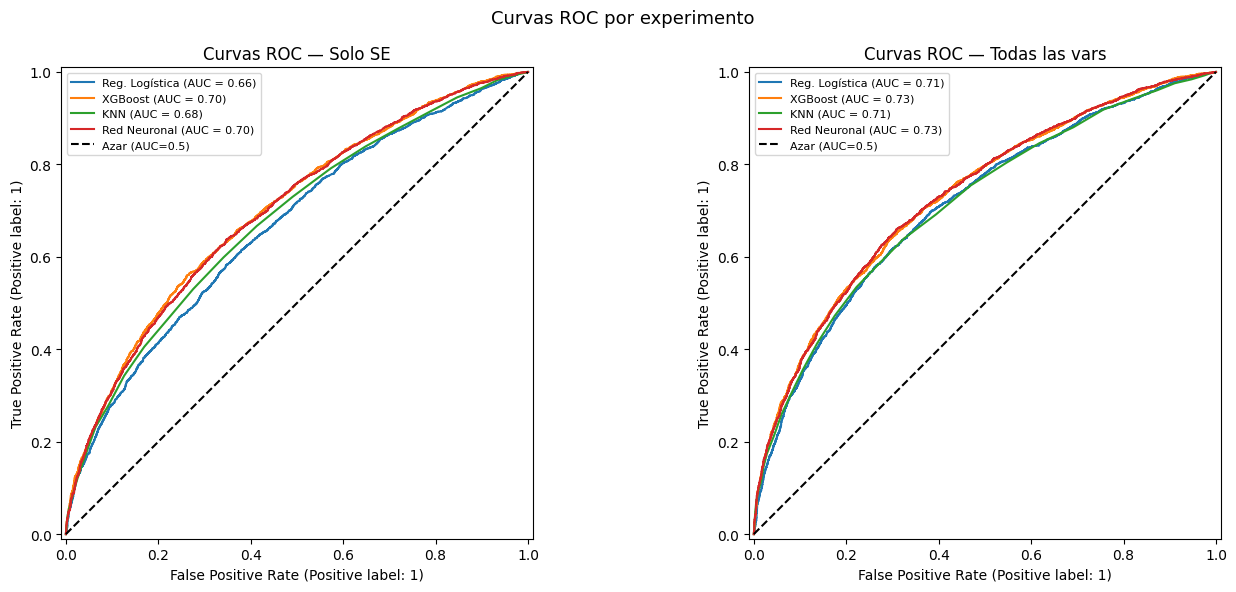

In [20]:
# COMENTADO: gráfica de puntaje real vs predicho — solo tiene sentido en regresión;
# en clasificación las predicciones son 0/1, no números continuos
# # Esta gráfica va al paper: muestra visualmente qué tan bien predice cada modelo
# fig, axes = plt.subplots(2, 3, figsize=(15, 10))
#
# for row, exp_name in enumerate(["exp1_se", "exp2_todas"]):
#     y_test = experimentos[exp_name]["y_test"].values
#
#     for col, (nombre, preds_dict) in enumerate([
#         ("Ridge",       preds_ridge),
#         ("XGBoost",     preds_xgb),
#         ("Red Neuronal",preds_nn),
#     ]):
#         ax = axes[row][col]
#         y_pred = preds_dict[exp_name]
#
#         ax.scatter(y_test, y_pred, alpha=0.15, s=5, color="steelblue")
#         # eje X → puntaje real, eje Y → puntaje predicho
#         # si el modelo fuera perfecto todos los puntos estarían en la diagonal
#
#         lim = [min(y_test.min(), y_pred.min()),
#                max(y_test.max(), y_pred.max())]
#         ax.plot(lim, lim, "r--", linewidth=1.5, label="Predicción perfecta")
#         # línea diagonal roja = predicción perfecta (predicho = real)
#         # los puntos cercanos a esta línea son buenas predicciones
#
#         r2 = r2_score(y_test, y_pred)
#         rmse = np.sqrt(mean_squared_error(y_test, y_pred))
#         ax.set_title(
#             f"{nombre}\n{'Solo SE' if exp_name=='exp1_se' else 'Todas'} "
#             f"| R²={r2:.3f} RMSE={rmse:.1f}",
#             fontsize=9
#         )
#         ax.set_xlabel("Puntaje real")
#         ax.set_ylabel("Puntaje predicho")
#         ax.legend(fontsize=7)
#
# plt.suptitle("Puntaje real vs predicho — todos los modelos", fontsize=13)
# plt.tight_layout()
# plt.savefig("../outputs/figures/predicciones_vs_reales.png", dpi=150)
# plt.show()

# PARA CLASIFICACIÓN: matrices de confusión y curvas ROC
modelos_preds = [
    ("Reg. Logística", preds_lr),
    ("XGBoost",        preds_xgb),
    ("KNN",            preds_knn),
    ("Red Neuronal",   preds_nn),
]

# ── Matrices de confusión ─────────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(20, 9))

for col, (nombre, preds_dict) in enumerate(modelos_preds):
    for row, exp_name in enumerate(["exp1_se", "exp2_todas"]):
        y_test = experimentos[exp_name]["y_test"].values
        y_pred, _ = preds_dict[exp_name]

        cm = confusion_matrix(y_test, y_pred)
        # filas = clase real, columnas = clase predicha
        # [0,0] → verdaderos negativos (bajo predicho como bajo)
        # [1,1] → verdaderos positivos (alto predicho como alto)
        # [0,1] → falsos positivos, [1,0] → falsos negativos

        ax = axes[row][col]
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                    xticklabels=["Pred Bajo", "Pred Alto"],
                    yticklabels=["Real Bajo", "Real Alto"])
        ax.set_title(
            f"{nombre}\n{'Solo SE' if exp_name=='exp1_se' else 'Todas'}",
            fontsize=9
        )

plt.suptitle("Matrices de confusión — todos los modelos", fontsize=13)
plt.tight_layout()
plt.savefig("../outputs/figures/matrices_confusion.png", dpi=150)
plt.show()

# ── Curvas ROC ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
colores_modelos = {
    "Reg. Logística": "#1f77b4",
    "XGBoost":        "#ff7f0e",
    "KNN":            "#2ca02c",
    "Red Neuronal":   "#d62728",
}

for ax, exp_name in zip(axes, ["exp1_se", "exp2_todas"]):
    y_test = experimentos[exp_name]["y_test"].values
    for nombre, preds_dict in modelos_preds:
        _, y_proba = preds_dict[exp_name]
        RocCurveDisplay.from_predictions(
            y_test, y_proba,
            name=nombre,
            color=colores_modelos[nombre],
            ax=ax
        )
    ax.plot([0, 1], [0, 1], "k--", label="Azar (AUC=0.5)")
    # línea diagonal = clasificador aleatorio, modelo debe estar sobre ella
    ax.set_title(f"Curvas ROC — {'Solo SE' if exp_name=='exp1_se' else 'Todas las vars'}")
    ax.legend(fontsize=8)

plt.suptitle("Curvas ROC por experimento", fontsize=13)
plt.tight_layout()
plt.savefig("../outputs/figures/curvas_roc.png", dpi=150)
plt.show()

# SHAP (importancia de variables para el paper)

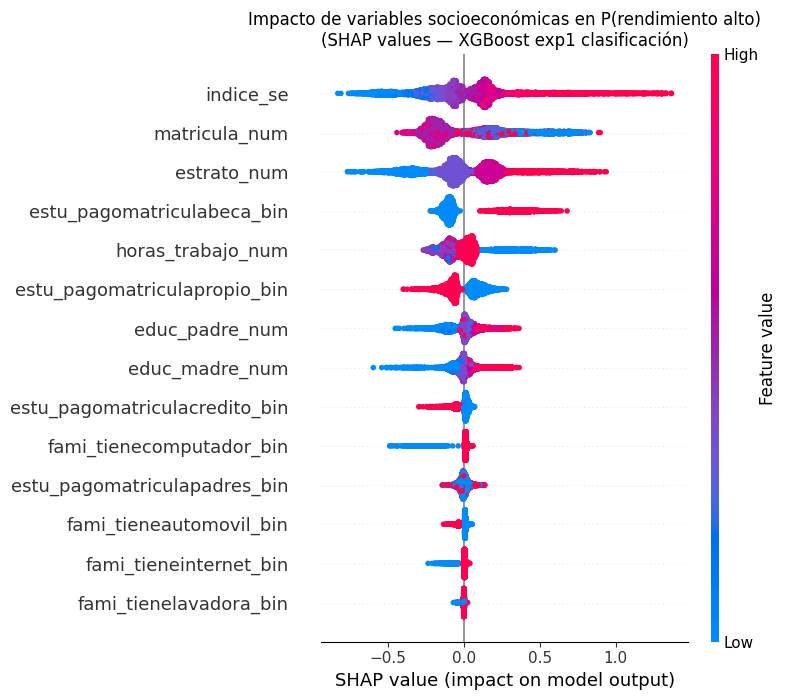

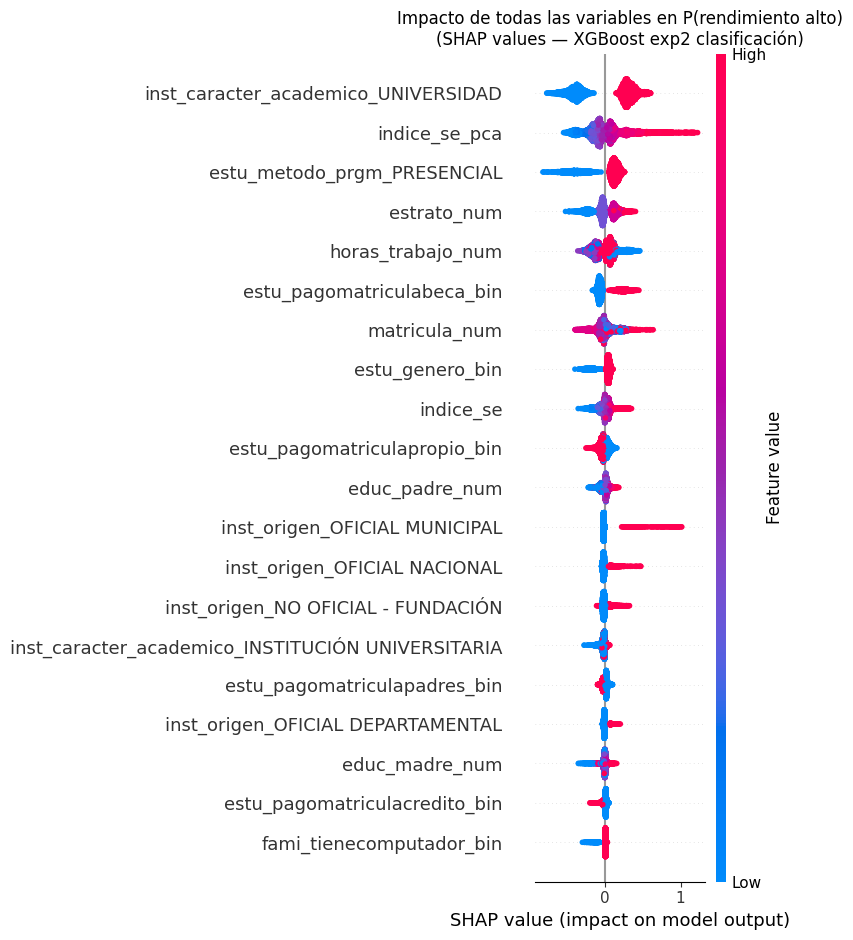

In [21]:
import shap

# SHAP en XGBoost exp1 (solo SE) → figura más importante del paper
# muestra qué variables socioeconómicas tienen más impacto en la PROBABILIDAD de rendir alto
modelo_xgb = joblib.load("../data/processed/xgb_exp1_se.pkl")
X_test_exp1 = experimentos["exp1_se"]["X_test"]

explainer = shap.TreeExplainer(modelo_xgb)
# TreeExplainer → versión optimizada de SHAP para modelos de árboles (XGBoost)
# calcula la contribución de cada variable a cada predicción

shap_values = explainer.shap_values(X_test_exp1)
# shap_values → matriz (n_estudiantes × n_features)
# cada número dice cuánto sube o baja la probabilidad de clase 1 por esa variable

plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values,
    X_test_exp1,
    show=False
    # show=False → no muestra inmediatamente, permite guardar primero
)
plt.title("Impacto de variables socioeconómicas en P(rendimiento alto)\n(SHAP values — XGBoost exp1 clasificación)")
plt.tight_layout()
plt.savefig("../outputs/figures/shap_exp1_se.png", dpi=150, bbox_inches="tight")
plt.show()
# este gráfico muestra:
# eje Y → variables ordenadas por importancia (la más importante arriba)
# eje X → cuántos puntos suma (derecha) o resta (izquierda) al puntaje
# color → rojo = valor alto de la variable, azul = valor bajo
# ejemplo: si estrato aparece arriba y rojo a la derecha →
#          estrato alto aumenta la probabilidad de rendir alto

# También para exp2 (todas las variables)
modelo_xgb2 = joblib.load("../data/processed/xgb_exp2_todas.pkl")
X_test_exp2 = experimentos["exp2_todas"]["X_test"]
explainer2  = shap.TreeExplainer(modelo_xgb2)
shap_values2 = explainer2.shap_values(X_test_exp2)

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values2, X_test_exp2, show=False)
plt.title("Impacto de todas las variables en P(rendimiento alto)\n(SHAP values — XGBoost exp2 clasificación)")
plt.tight_layout()
plt.savefig("../outputs/figures/shap_exp2_todas.png", dpi=150, bbox_inches="tight")
plt.show()